# 3.nivelSesionReprAcustica · CNN **regresora** (coherente con la línea principal)

Reformulación de la CNN como **regresor del PHQ-8 continuo**, en lugar de clasificador binario.

**Motivo.** El trabajo plantea el problema como regresión sobre el PHQ-8, derivando la decisión
binaria mediante un umbral. La versión anterior de la CNN se entrenaba directamente como
clasificador (salida sigmoide, pérdida `binary_crossentropy`), lo que rompía esa coherencia: sus
predicciones no eran puntos de PHQ-8 y su umbral no era comparable con el del resto de modelos.

**Cambios respecto a la versión anterior:**
- Capa de salida: `Dense(1, activation='linear')` en lugar de sigmoide.
- Pérdida: **MSE** en lugar de entropía cruzada binaria.
- Objetivo: **PHQ-8 continuo** en lugar de la etiqueta binarizada.
- El submuestreo, que antes equilibraba clases, pasa a ser un **muestreo estratificado por
  severidad**: cada miembro del ensemble ve una proporción equilibrada de casos por encima y por
  debajo del umbral clínico. No se clasifica; solo se equilibra la composición de la muestra.
- Se **mantienen** el ensemble de 5 redes, SpecAugment y la regularización.

El resto del protocolo es idéntico: agregación ventana→sujeto, umbral ajustado sobre `dev` y
evaluación única en test.

## 0. Setup

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np, pandas as pd, random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             precision_recall_fscore_support, confusion_matrix,
                             ConfusionMatrixDisplay, mean_squared_error, mean_absolute_error, r2_score)
import warnings; warnings.filterwarnings('ignore')

RANDOM_STATE, PHQ_THRESHOLD = 42, 10
tf.get_logger().setLevel('ERROR')
from pathlib import Path
PROJECT_DIR = Path.home().as_posix() + '/Desktop/Master/UNIR_IA_TFE'   # ruta local del proyecto
path_output = PROJECT_DIR + '/output'

K_ENSEMBLE = 5      # nº de redes del ensemble
EPOCHS     = 30
PATIENCE   = 6
BATCH      = 64
LR         = 5e-4
L2         = 1e-4
DROPOUT    = 0.5
FREQ_MASK  = 24     # SpecAugment: ancho máx. de banda de frecuencia enmascarada
TIME_MASK  = 32     # SpecAugment: ancho máx. de banda temporal

## 1. Carga y partición por sujeto

In [2]:
X = np.load(path_output + '/spectrograms_128.npy')[..., np.newaxis].astype('float32')
man = pd.read_csv(path_output + '/df_spectrogram_manifest.csv')

y   = man['phq8_score'].values.astype('float32')      # <-- TARGET CONTINUO
ybin = (y >= PHQ_THRESHOLD).astype(int)               # solo para estratificar y evaluar
spl = man['split'].values; pid = man['participant_id'].values
tr, dv, te = (spl=='train'), (spl=='dev'), (spl=='test')
assert not (set(pid[tr]) & set(pid[te])) and not (set(pid[dv]) & set(pid[te])), 'FUGA entre particiones'

Xtr, ytr = X[tr], y[tr]
Xdv, ydv = X[dv], y[dv]
Xte      = X[te]
print(f"Ventanas -> train {tr.sum()} | dev {dv.sum()} | test {te.sum()}")
print(f"PHQ-8 medio: train {ytr.mean():.2f} | dev {ydv.mean():.2f}")
print('Sin solape de sesiones entre particiones: OK')

Ventanas -> train 10276 | dev 3611 | test 5245
PHQ-8 medio: train 6.04 | dev 8.53
Sin solape de sesiones entre particiones: OK


## 2. Arquitectura (regresora), SpecAugment y muestreo estratificado

In [3]:
def _mask_band(x, axis, max_w):
    dim = 128
    w  = tf.random.uniform([], 1, max_w, dtype=tf.int32)
    s0 = tf.random.uniform([], 0, dim - w, dtype=tf.int32)
    idx = tf.range(dim)
    keep = tf.cast(tf.logical_or(idx < s0, idx >= s0 + w), x.dtype)
    keep = tf.reshape(keep, (dim, 1, 1) if axis == 0 else (1, dim, 1))
    return x * keep

def spec_augment(x, y):
    x = _mask_band(x, 0, FREQ_MASK)
    x = _mask_band(x, 1, TIME_MASK)
    return x, y

def build_cnn():
    """Misma arquitectura que la versión anterior, con salida LINEAL y pérdida MSE."""
    reg = keras.regularizers.l2(L2)
    m = keras.Sequential(name='cnn_mel_reg', layers=[
        keras.layers.Input((128, 128, 1)),
        keras.layers.Conv2D(16, 3, padding='same', kernel_regularizer=reg),
        keras.layers.BatchNormalization(), keras.layers.ReLU(), keras.layers.MaxPool2D(2),
        keras.layers.Conv2D(32, 3, padding='same', kernel_regularizer=reg),
        keras.layers.BatchNormalization(), keras.layers.ReLU(), keras.layers.MaxPool2D(4),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dropout(DROPOUT),
        keras.layers.Dense(1, activation='linear', kernel_regularizer=reg),   # <-- REGRESION
    ])
    m.compile(optimizer=keras.optimizers.Adam(LR), loss='mse',
              metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])
    return m

def stratified_idx(ybin_tr, seed):
    """Submuestra equilibrada por severidad (no es clasificación: solo compone la muestra)."""
    rng = np.random.RandomState(seed)
    alto = np.where(ybin_tr == 1)[0]; bajo = np.where(ybin_tr == 0)[0]
    bajo_s = rng.choice(bajo, size=len(alto), replace=False)
    idx = np.concatenate([alto, bajo_s]); rng.shuffle(idx)
    return idx

build_cnn().summary()

Model: "cnn_mel_reg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,025 (19.63 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 96 (384.00 B)

## 3. Entrenamiento del ensemble

In [4]:
ybin_tr = ybin[tr]
test_pred, dev_pred, histories = [], [], []
for k in range(K_ENSEMBLE):
    keras.utils.set_random_seed(RANDOM_STATE + k)
    idx = stratified_idx(ybin_tr, seed=RANDOM_STATE + k)
    ds = (tf.data.Dataset.from_tensor_slices((Xtr[idx], ytr[idx]))
          .shuffle(4000, seed=k).map(spec_augment, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH).prefetch(tf.data.AUTOTUNE))
    m = build_cnn()
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)
    h = m.fit(ds, validation_data=(Xdv, ydv), epochs=EPOCHS, callbacks=[es], verbose=2)
    histories.append(h.history)
    test_pred.append(m.predict(Xte, batch_size=128, verbose=0).ravel())
    dev_pred.append(m.predict(Xdv, batch_size=128, verbose=0).ravel())
    print(f"  · red {k+1}/{K_ENSEMBLE}: mejor val_loss (MSE) {min(h.history['val_loss']):.3f}")

p_te = np.mean(test_pred, axis=0)      # PHQ-8 predicho por ventana
p_dv = np.mean(dev_pred, axis=0)
print('\nEnsemble listo.')

Epoch 1/30
95/95 - 31s - 326ms/step - loss: 48.7364 - rmse: 6.9810 - val_loss: 116.1072 - val_rmse: 10.7752
Epoch 2/30
95/95 - 26s - 274ms/step - loss: 40.1777 - rmse: 6.3384 - val_loss: 110.1960 - val_rmse: 10.4973
Epoch 3/30
95/95 - 25s - 262ms/step - loss: 37.8859 - rmse: 6.1549 - val_loss: 97.6398 - val_rmse: 9.8812
Epoch 4/30
95/95 - 25s - 262ms/step - loss: 36.7933 - rmse: 6.0655 - val_loss: 86.2147 - val_rmse: 9.2850
Epoch 5/30
95/95 - 25s - 268ms/step - loss: 35.9006 - rmse: 5.9915 - val_loss: 72.3885 - val_rmse: 8.5080
Epoch 6/30
95/95 - 25s - 267ms/step - loss: 35.0313 - rmse: 5.9185 - val_loss: 63.6945 - val_rmse: 7.9807
Epoch 7/30
95/95 - 25s - 263ms/step - loss: 34.8975 - rmse: 5.9072 - val_loss: 61.2246 - val_rmse: 7.8244
Epoch 8/30
95/95 - 25s - 263ms/step - loss: 35.1228 - rmse: 5.9262 - val_loss: 55.7161 - val_rmse: 7.4641
Epoch 9/30
95/95 - 25s - 263ms/step - loss: 35.3047 - rmse: 5.9415 - val_loss: 54.6790 - val_rmse: 7.3943
Epoch 10/30
95/95 - 25s - 263ms/step - los

## 4. Agregación a sujeto y evaluación

In [5]:
def to_subject(mask, pred):
    d = man.loc[mask, ['participant_id','phq8_score']].copy(); d['p'] = pred
    g = d.groupby('participant_id').agg(p=('p','mean'), score=('phq8_score','first'))
    g['y'] = (g['score'] >= PHQ_THRESHOLD).astype(int)
    return g

g_dv, g_te = to_subject(dv, p_dv), to_subject(te, p_te)

# umbral en PHQ-8 (mismas unidades que el resto de modelos), ajustado sobre dev
ths = np.linspace(g_dv['p'].min(), g_dv['p'].max(), 200)
thr = ths[int(np.argmax([f1_score(g_dv['y'], (g_dv['p'] >= t).astype(int), zero_division=0) for t in ths]))]

yv, pv = g_te['y'].values, g_te['p'].values
print('── REGRESIÓN (nivel sujeto) ──')
print(f"  RMSE {np.sqrt(mean_squared_error(g_te['score'], pv)):.3f} | "
      f"MAE {mean_absolute_error(g_te['score'], pv):.3f} | R² {r2_score(g_te['score'], pv):.3f}")
print('\n── CLASIFICACIÓN DERIVADA (nivel sujeto) ──')
print(f"  AUC {roc_auc_score(yv, pv):.3f}")
_,_,bf,_ = precision_recall_fscore_support(yv, np.ones(len(yv)), average='binary', zero_division=0)
print(f"  Línea base trivial (marcar a todos): F1 {bf:.3f}")
for nom, t in [('nominal (>=10)', PHQ_THRESHOLD), (f'óptimo dev ({thr:.2f})', thr)]:
    yh = (pv >= t).astype(int)
    p_, r_, f_, _ = precision_recall_fscore_support(yv, yh, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(yv, yh).ravel()
    print(f"  [{nom:<20}] Prec {p_:.3f} Rec {r_:.3f} F1 {f_:.3f} Acc {accuracy_score(yv,yh):.3f}"
          f"  TP {tp} FP {fp} FN {fn} TN {tn}")
print('\n  Referencia: RF sesión AUC 0.743 / F1 0.509')

── REGRESIÓN (nivel sujeto) ──
  RMSE 6.497 | MAE 5.505 | R² -0.027

── CLASIFICACIÓN DERIVADA (nivel sujeto) ──
  AUC 0.502
  Línea base trivial (marcar a todos): F1 0.467
  [nominal (>=10)      ] Prec 0.000 Rec 0.000 F1 0.000 Acc 0.696  TP 0 FP 0 FN 14 TN 32
  [óptimo dev (6.88)   ] Prec 0.300 Rec 0.643 F1 0.409 Acc 0.435  TP 9 FP 21 FN 5 TN 11

  Referencia: RF sesión AUC 0.743 / F1 0.509


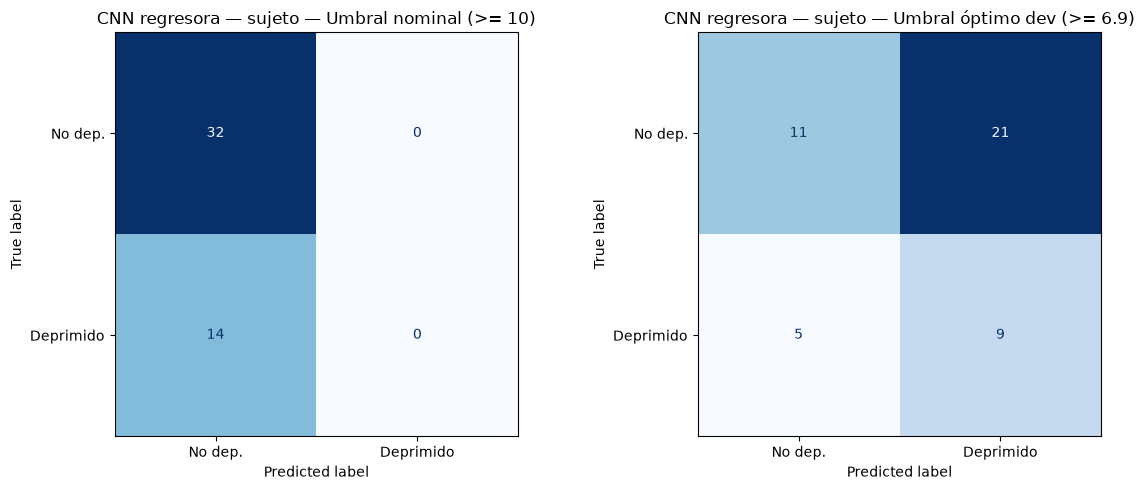

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, t, ttl in [(axes[0], PHQ_THRESHOLD, f'Umbral nominal (>= {PHQ_THRESHOLD})'),
                   (axes[1], thr, f'Umbral óptimo dev (>= {thr:.1f})')]:
    ConfusionMatrixDisplay.from_predictions(yv, (pv >= t).astype(int),
        display_labels=['No dep.','Deprimido'], colorbar=False, ax=ax, cmap='Blues')
    ax.set_title(f'CNN regresora — sujeto — {ttl}')
plt.tight_layout(); plt.show()